# FMSR Class 4 – Descriptive Statistics
**Minor Data Driven Decision Making in Business – uitwerking van de opdrachten**

Dit notebook werkt de vier opdrachten uit de slides van Class 4 uit:

1. **Exercise Descriptives (1)** – maten van centrale tendens + mean vs. median
2. **Exercise Descriptives (2)** – spreidingsmaten, visualisatie, welke variabele varieert meer
3. **Exercise Coefficient of Variation** – CV van lengte en cijfer (het `.py`-script ingevuld)
4. **Exercise Olympic Athletes** – kansen berekenen met de normale verdeling

Werkwijze per stap: eerst *wat* en *waarom*, dan de code, daarna *wat betekent de output* en *wat is de volgende stap*.

## 0. Business Understanding

**Vraag:** hoe ziet de 3DMiB-minorgroep eruit qua achtergrond, programmeertaal, statistiekniveau, verwacht cijfer en lengte?

**Waarom relevant:** een docent kan met dit profiel de lessen afstemmen (bijv. meer basisstatistiek als het niveau laag is, voorbeelden in Python of R). Een verkeerd beeld van de groep (bijv. een gemiddelde dat door een uitschieter wordt vertekend) leidt tot lessen die te makkelijk of te moeilijk zijn.

**Let op:** de groep (n = 24) is een *steekproef* als we iets willen zeggen over "minorstudenten in het algemeen" en een *populatie* als we alleen deze groep beschrijven. Dat onderscheid komt terug bij de keuze voor `ddof=1` (zie opdracht 2 en 3).

## 1. Data Understanding – data inladen en bekijken

**Wat:** we laden `minor_survey.xlsx` in een pandas DataFrame en bekijken de structuur, datatypes en ontbrekende waarden.
**Waarom:** voordat we iets berekenen moeten we weten welke variabelen *categorisch* zijn (→ frequenties/modus) en welke *numeriek* (→ mean/median/spreiding), en of er missende data is (np.median kan daar niet mee overweg, zie slide 8).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

data = pd.read_excel('minor_survey.xlsx')

print('Aantal rijen en kolommen:', data.shape)
display(data.head())
print(data.dtypes)
print('\nOntbrekende waarden per kolom:')
print(data.isna().sum())

Aantal rijen en kolommen: (24, 6)


,survey_id,han_student,programming_language,statistics_proficiency,expected_grade,length
0,1,no,python,2.0,9.0,160
1,2,yes,python,2.0,7.5,164
2,3,yes,python,NaN,5.5,186
3,4,yes,python,1.0,5.5,185
4,5,no,python,2.0,6.5,177


survey_id                   int64
han_student                   str
programming_language          str
statistics_proficiency    float64
expected_grade            float64
length                      int64
dtype: object

Ontbrekende waarden per kolom:
survey_id                 0
han_student               0
programming_language      0
statistics_proficiency    1
expected_grade            0
length                    0
dtype: int64


**Interpretatie:** de dataset bevat 24 respondenten en 6 kolommen. `survey_id` is alleen een volgnummer en analyseren we niet.

| Variabele | Type | Juiste maat |
|---|---|---|
| `han_student` | categorisch (ja/nee) | frequentie, proportie, modus |
| `programming_language` | categorisch | frequentie, proportie, modus |
| `statistics_proficiency` | ordinaal (schaal 1–5) | modus en mediaan (gemiddelde met voorzichtigheid) |
| `expected_grade` | numeriek (continu) | mean, median, spreiding |
| `length` | numeriek (cm) | mean, median, spreiding |

Er is **één ontbrekende waarde** in `statistics_proficiency` (respondent 3). Daarom gebruiken we bij die kolom `.dropna()` (n = 23).
**Volgende stap:** centrale tendens berekenen, apart voor categorische en numerieke variabelen.

---
## 2. Exercise Descriptives (1)
### A) Maten van centrale tendens – categorische variabelen

**Wat:** voor `han_student`, `programming_language` en `statistics_proficiency` berekenen we de frequentie (`value_counts()`), de proportie (`normalize=True`) en de modus.
**Waarom:** bij categorische data bestaat geen gemiddelde; de vraag is "hoe vaak komt elke categorie voor en welke het meest?" (slide 9). Verwachting: vrijwel iedereen gebruikt Python, want dat is de taal van de minor.

In [3]:
categorical = ['han_student', 'programming_language', 'statistics_proficiency']

for col in categorical:
    freq = data[col].value_counts()
    prop = data[col].value_counts(normalize=True).round(3)
    table = pd.DataFrame({'frequentie': freq, 'proportie': prop})
    print(f'=== {col} ===')
    print(table)
    print('Modus:', data[col].mode().tolist(), '\n')

=== han_student ===
             frequentie  proportie
han_student                       
yes                  20      0.833
no                    4      0.167
Modus: ['yes'] 

=== programming_language ===
                      frequentie  proportie
programming_language                       
python                        23      0.958
r                              1      0.042
Modus: ['python'] 

=== statistics_proficiency ===
                        frequentie  proportie
statistics_proficiency                       
2.0                             10      0.435
1.0                              6      0.261
3.0                              4      0.174
4.0                              2      0.087
5.0                              1      0.043
Modus: [2.0] 



**Interpretatie:**
- **HAN-student:** 20 van de 24 (83,3%) zijn HAN-studenten, 4 (16,7%) komen van een andere instelling. Modus = *yes*.
- **Programmeertaal:** 23 van de 24 (95,8%) werken met Python, 1 met R. Modus = *python*. Lesmateriaal in Python sluit dus aan bij bijna de hele groep.
- **Statistiekniveau (1–5):** de modus is **2** (43,5%); samen met niveau 1 scoort 70% zichzelf op 1 of 2. Slechts 3 studenten geven zichzelf een 4 of 5.

Voor de docent betekent dit dat de groep vooral uit HAN-studenten bestaat die Python gebruiken, maar dat het statistiekniveau laag is. Basisconcepten (zoals in deze les) uitgebreid behandelen is dus terecht.
**Volgende stap:** de numerieke variabelen beschrijven met mean, median en modus.

### A) Maten van centrale tendens – numerieke variabelen

**Wat:** voor `expected_grade` en `length` (en ter vergelijking `statistics_proficiency`) berekenen we mean, median en modus met NumPy/pandas, zoals op slide 8.
**Waarom:** het gemiddelde en de mediaan geven samen het "midden" van de data; als ze ver uit elkaar liggen wijst dat op scheefheid of uitschieters (vraag B).

In [4]:
numerical = ['statistics_proficiency', 'expected_grade', 'length']

rows = []
for col in numerical:
    x = data[col].dropna()            # np.median can't handle NaN -> dropna()
    rows.append({
        'variabele': col,
        'n': len(x),
        'mean': np.mean(x),
        'median': np.median(x),
        'modus': x.mode().tolist(),
    })

central = pd.DataFrame(rows).set_index('variabele')
central.round(2)

,n,mean,median,modus
variabele,,,,
statistics_proficiency,23,2.22,2.0,[2.0]
expected_grade,24,7.31,7.0,"[7.0, 8.0]"
length,24,177.79,180.0,[180]


**Interpretatie:**
- **Verwacht cijfer:** gemiddeld **7,31**, mediaan **7,0**. Er zijn twee modi (7,0 en 8,0, elk 6×). De groep verwacht dus gemiddeld een ruime voldoende.
- **Lengte:** gemiddeld **177,8 cm**, mediaan **180 cm**, modus 180 cm. Het gemiddelde ligt ruim 2 cm *onder* de mediaan.
- **Statistiekniveau:** mean 2,22, mediaan 2. Omdat dit een ordinale schaal is (de afstand tussen 1 en 2 is niet per se gelijk aan die tussen 4 en 5), is de mediaan/modus hier de zuiverste maat.

**Volgende stap:** vraag B beantwoorden: welke maat (mean of median) beschrijft het midden het best?

### B) Mean of median: wat is beter?

**Wat:** we zetten mean en median naast elkaar, berekenen de scheefheid (skewness) en zoeken uitschieters met de IQR-regel (waarden < Q1 − 1,5·IQR of > Q3 + 1,5·IQR).
**Waarom:** volgens slide 12–14 hangt het antwoord af van de data. Het gemiddelde is gevoelig voor uitschieters en scheefheid, de mediaan niet. We moeten dus eerst kijken of daar sprake van is.

In [5]:
for col in ['expected_grade', 'length']:
    x = data[col]
    q1, q3 = x.quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = x[(x < low) | (x > high)].tolist()
    print(f'{col}: mean = {x.mean():.2f}, median = {x.median():.2f}, '
          f'verschil = {x.mean() - x.median():+.2f}, skewness = {x.skew():.2f}')
    print(f'   IQR-grenzen: [{low:.1f}, {high:.1f}] -> uitschieters: {outliers}\n')

expected_grade: mean = 7.31, median = 7.00, verschil = +0.31, skewness = 0.06
   IQR-grenzen: [4.2, 10.2] -> uitschieters: []

length: mean = 177.79, median = 180.00, verschil = -2.21, skewness = -0.59
   IQR-grenzen: [152.5, 204.5] -> uitschieters: []



**Interpretatie / antwoord op B:**
- **Verwacht cijfer:** mean (7,31) en median (7,0) liggen dicht bij elkaar, skewness ≈ 0,06 (bijna symmetrisch) en er zijn geen uitschieters. Het **gemiddelde** is hier prima bruikbaar.
- **Lengte:** de verdeling is iets **links-scheef** (skewness ≈ −0,59; mean < median, precies zoals op slide 18). Er zijn geen formele uitschieters, maar een paar kortere studenten (160–169 cm) trekken het gemiddelde naar beneden. De **mediaan** (180 cm) beschrijft de "typische" student hier iets beter; het verschil is met ~2 cm wel klein.

**Algemeen antwoord:** gebruik het gemiddelde als de data ongeveer symmetrisch is en geen extreme uitschieters heeft; gebruik de mediaan bij scheve data of uitschieters (bijv. inkomen, slide 14). Bij een kleine groep zoals deze (n = 24) kan één persoon het gemiddelde al flink verschuiven, dus het is verstandig beide te rapporteren.
**Volgende stap:** de spreiding van de numerieke variabelen bekijken (Exercise 2).

---
## 3. Exercise Descriptives (2)
### A) Spreidingsmaten voor de numerieke variabelen

**Wat:** voor `expected_grade` en `length` berekenen we range, variantie en standaarddeviatie, zowel de **populatie**-versie (`ddof=0`, NumPy-standaard) als de **steekproef**-versie (`ddof=1`, Bessel-correctie, pandas-standaard; slide 22).
**Waarom:** het midden alleen zegt niet hoe "gelijk" de groep is. Twee groepen met hetzelfde gemiddelde kunnen heel verschillend gespreid zijn (slide 21).

In [6]:
rows = []
for col in ['expected_grade', 'length']:
    x = data[col]
    rows.append({
        'variabele': col,
        'min': np.min(x),
        'max': np.max(x),
        'range': np.max(x) - np.min(x),
        'var (ddof=0)': np.var(x),
        'var (ddof=1)': np.var(x, ddof=1),
        'std (ddof=0)': np.std(x),
        'std (ddof=1)': np.std(x, ddof=1),
    })

variation = pd.DataFrame(rows).set_index('variabele')
variation.round(3)

,min,max,range,var (ddof=0),var (ddof=1),std (ddof=0),std (ddof=1)
variabele,,,,,,,
expected_grade,5.5,9.2,3.7,1.166,1.217,1.080,1.103
length,160.0,191.0,31.0,77.415,80.781,8.799,8.988


**Interpretatie:**
- **Verwacht cijfer:** range = 9,2 − 5,5 = **3,7 punten**; standaarddeviatie (steekproef) ≈ **1,10**. Een typische student zit dus ongeveer 1,1 punt van het gemiddelde (7,31) af.
- **Lengte:** range = 191 − 160 = **31 cm**; standaarddeviatie (steekproef) ≈ **8,99 cm**.
- De variantie is lastig te lezen omdat de eenheid in het kwadraat staat (cm², cijfer²). Daarom rapporteren we de standaarddeviatie.
- **ddof=0 of ddof=1?** Zien we de 24 studenten als steekproef van alle minorstudenten, dan gebruiken we **ddof=1** (n − 1). Bij n = 24 is het verschil klein (8,80 vs. 8,99 cm), maar bij kleine groepen onderschat ddof=0 de echte spreiding systematisch.

**Volgende stap:** de verdelingen visualiseren, zodat we scheefheid en spreiding ook zien in plaats van alleen in getallen.

### B) De verdeling van de variabelen visualiseren

**Wat:** een **staafdiagram** voor de categorische variabelen en een **histogram** voor de numerieke variabelen (slide 17), met mean en median als verticale lijnen.
**Waarom:** in een grafiek zie je direct of een verdeling symmetrisch of scheef is en waar de uitschieters zitten. Dat bevestigt (of weerlegt) de conclusie bij 1B.

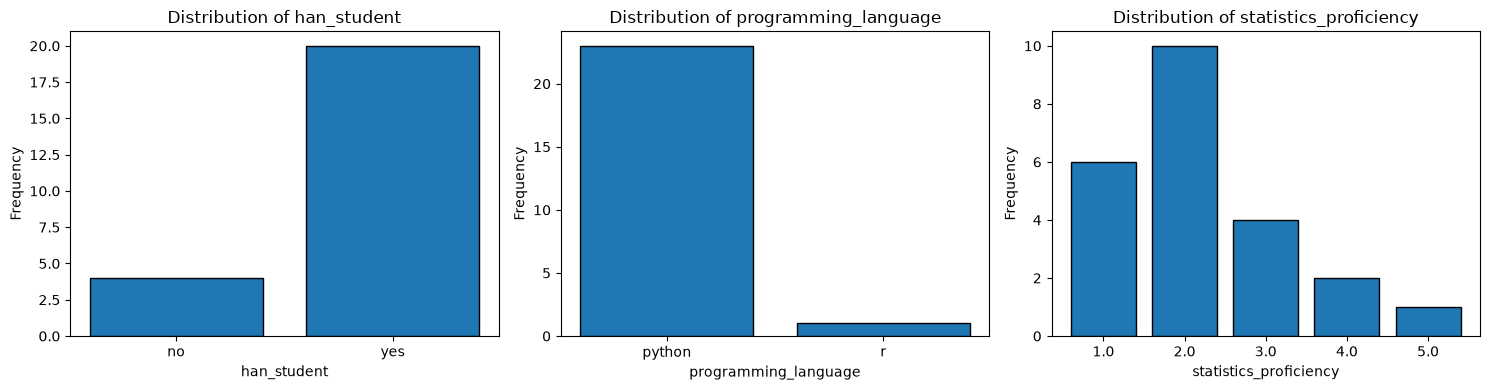

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, categorical):
    counts = data[col].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values, edgecolor='black')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

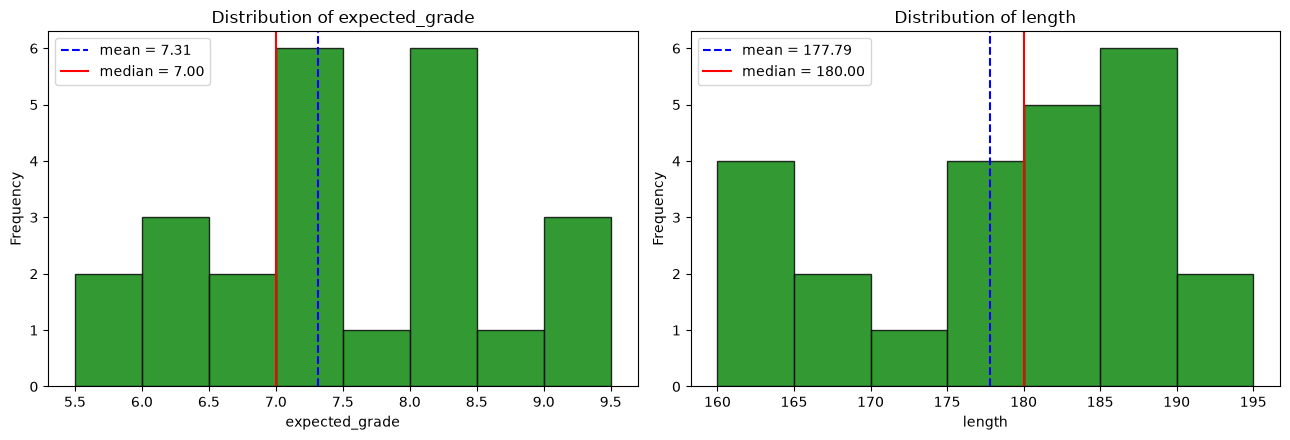

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
settings = {'expected_grade': np.arange(5.5, 9.75, 0.5),
            'length': np.arange(160, 196, 5)}

for ax, (col, bins) in zip(axes, settings.items()):
    x = data[col]
    ax.hist(x, bins=bins, color='green', edgecolor='black', alpha=0.8)
    ax.axvline(x.mean(), color='blue', linestyle='--', label=f'mean = {x.mean():.2f}')
    ax.axvline(x.median(), color='red', linestyle='-', label=f'median = {x.median():.2f}')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.legend()
plt.tight_layout()
plt.show()

**Interpretatie:**
- De staafdiagrammen bevestigen de scheve verhoudingen bij de categorische variabelen: bijna iedereen is HAN-student en gebruikt Python, en statistiekniveau 2 springt eruit.
- **Verwacht cijfer:** de waarden liggen redelijk verspreid tussen 5,5 en 9,2, zonder duidelijke staart. Mean en median liggen dicht bij elkaar.
- **Lengte:** het grootste deel van de groep zit tussen 175 en 190 cm, met een **staart naar links** (enkele studenten van 160–169 cm). Daardoor ligt het gemiddelde links van de mediaan, wat de links-scheve verdeling uit 1B bevestigt.

**Volgende stap:** vraag C. Welke variabele varieert meer? Dat kunnen we niet direct aflezen uit de standaarddeviaties, omdat de eenheden verschillen (cm vs. cijferpunten).

### C) Welke variabele varieert meer: lengte of cijfer?

**Wat:** we vergelijken de standaarddeviaties en zien dat de vergelijking scheef is.
**Waarom:** een SD van 8,99 lijkt veel groter dan 1,10, maar dat komt alleen doordat lengte in centimeters wordt gemeten en rond 178 ligt, terwijl cijfers rond 7 liggen. Voor een eerlijke vergelijking moet de spreiding *relatief* aan het gemiddelde worden uitgedrukt: dat is de **coëfficiënt van variatie** (slide 23). Die berekenen we in de volgende opdracht.

---
## 4. Exercise Coefficient of Variation

**Wat:** we vullen het script `exercise_coefficient_of_variation.py` in en berekenen de CV van `length` en `expected_grade`:

$$CV = \frac{s}{\bar{x}} \cdot 100\%$$

**Waarom:** de CV is eenheidsloos, dus we kunnen variabelen met verschillende eenheden en gemiddelden vergelijken (zoals de aandelen A en B op slide 24).

**Keuze ddof=1?** Ja. De 24 respondenten zijn een steekproef, dus we gebruiken de steekproef-standaarddeviatie *s* (`ddof=1`). Let op: `np.std()` corrigeert standaard **niet**, pandas `.std()` wel (slide 22).

In [9]:
# Computing the coefficient of variation for the minor survey data
import numpy as np
import pandas as pd

# Specify the survey data
data = pd.read_excel('minor_survey.xlsx')

# CV = sample standard deviation / mean * 100%
# ddof=1 -> sample standard deviation (Bessel's correction), because our group is a sample
cv = lambda x: np.std(x, ddof=1) / np.mean(x) * 100

# Compute cv for the variables
cv_1 = cv(data['length'])
cv_2 = cv(data['expected_grade'])

# Print the results
print(f'CV length:         {cv_1:.2f}%')
print(f'CV expected_grade: {cv_2:.2f}%')

# For comparison: without the correction (ddof=0)
cv_pop = lambda x: np.std(x) / np.mean(x) * 100
print(f'\n(ddof=0) CV length: {cv_pop(data["length"]):.2f}%, '
      f'CV expected_grade: {cv_pop(data["expected_grade"]):.2f}%')

CV length:         5.06%
CV expected_grade: 15.08%

(ddof=0) CV length: 4.95%, CV expected_grade: 14.77%


**Interpretatie / antwoord op Exercise 2C:**
- **CV lengte ≈ 5,06%**: de standaarddeviatie (8,99 cm) is maar ongeveer 5% van de gemiddelde lengte (177,8 cm).
- **CV verwacht cijfer ≈ 15,08%**: de standaarddeviatie (1,10) is ongeveer 15% van het gemiddelde cijfer (7,31).

**Conclusie:** het **verwachte cijfer varieert relatief ongeveer 3× zo sterk als de lengte**, terwijl de absolute standaarddeviatie van lengte juist veel groter is. Dit is precies de valkuil die de CV oplost. Studenten lijken qua lengte dus veel meer op elkaar dan qua verwachtingen over hun cijfer.

Voor de docent betekent dit dat de verwachtingen over het eindresultaat uiteenlopen (van een 5,5 tot een 9,2). In combinatie met het lage statistiekniveau is het nuttig om vroeg duidelijk te maken wat er nodig is voor een voldoende.
De keuze voor ddof=0 of ddof=1 verandert de conclusie niet (4,95% vs. 14,77%).
**Volgende stap:** de normale verdeling gebruiken om de lengte van de minorgroep te vergelijken met die van Olympische atleten.

---
## 5. Exercise Olympic Athletes

**Wat:** we laden `olympic_athlete_database.csv` (Brightspace, FMSR Class 4), berekenen het gemiddelde (μ) en de standaarddeviatie (σ) van de atletenlengtes en modelleren lengte als normale verdeling $N(\mu, \sigma)$. Daarna beantwoorden we de drie vragen met de cumulatieve verdelingsfunctie (CDF, slide 29–31):

1. $P(X > \text{langste student}) = 1 - \text{norm.cdf}(\max)$
2. $P(X < \text{kortste student}) = \text{norm.cdf}(\min)$
3. $P(\min \le X \le \max) = \text{norm.cdf}(\max) - \text{norm.cdf}(\min)$

**Waarom normale verdeling:** menselijke lengte is bij benadering normaal verdeeld (klokvormig en symmetrisch, slide 28), en het histogram op slide 33 volgt de normale curve goed. Dat controleren we hieronder ook visueel.

> **Let op:** zet `olympic_athlete_database.csv` in dezelfde map als dit notebook. De code zoekt zelf de kolom met lengte (een kolomnaam met *height*) en filtert ontbrekende en onmogelijke waarden (0 of leeg) weg.

In [10]:
import os

survey = pd.read_excel('minor_survey.xlsx')
min_student = survey['length'].min()   # shortest student in the minor group
max_student = survey['length'].max()   # tallest student in the minor group
print(f'Kortste student: {min_student} cm, langste student: {max_student} cm')

olympic_file = 'olympic_athlete_database.csv'
olympic_available = os.path.exists(olympic_file)

if olympic_available:
    athletes = pd.read_csv(olympic_file)
    height_col = [c for c in athletes.columns if 'height' in c.lower()][0]
    heights = pd.to_numeric(athletes[height_col], errors='coerce')
    heights = heights[heights > 0].dropna()          # remove missing / zero heights

    mu = heights.mean()
    sigma = heights.std()                             # pandas std -> ddof=1
    print(f'Kolom gebruikt: {height_col!r}')
    print(f'Aantal atleten met een geldige lengte: {len(heights):,}')
    print(f'Gemiddelde lengte (mu) = {mu:.2f} cm, standaarddeviatie (sigma) = {sigma:.2f} cm')
else:
    print(f'Bestand {olympic_file!r} niet gevonden. Download het van Brightspace '
          'en zet het in dezelfde map als dit notebook.')

Kortste student: 160 cm, langste student: 191 cm
Kolom gebruikt: 'height'
Aantal atleten met een geldige lengte: 105,112
Gemiddelde lengte (mu) = 176.33 cm, standaarddeviatie (sigma) = 10.36 cm


**Controle normaliteit:** we tekenen een genormaliseerd histogram (`density=True`) van de atletenlengtes met de normale curve $N(\mu, \sigma)$ eroverheen, net als op slide 33. Valt de curve goed over de staven, dan is het normale model verantwoord.

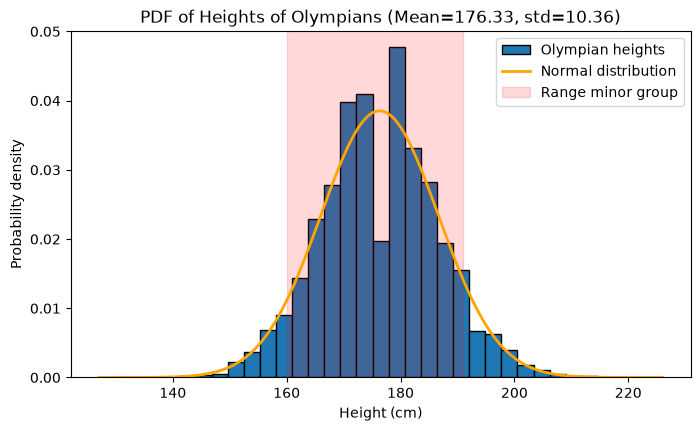

In [11]:
if olympic_available:
    xs = np.linspace(heights.min(), heights.max(), 300)
    plt.figure(figsize=(8, 4.5))
    plt.hist(heights, bins=35, density=True, edgecolor='black', label='Olympian heights')
    plt.plot(xs, norm.pdf(xs, mu, sigma), color='orange', lw=2, label='Normal distribution')
    plt.axvspan(min_student, max_student, color='red', alpha=0.15, label='Range minor group')
    plt.title(f'PDF of Heights of Olympians (Mean={mu:.2f}, std={sigma:.2f})')
    plt.xlabel('Height (cm)')
    plt.ylabel('Probability density')
    plt.legend()
    plt.show()

In [12]:
if olympic_available:
    # 1) P(athlete taller than the tallest student)
    p_taller = 1 - norm.cdf(max_student, loc=mu, scale=sigma)

    # 2) P(athlete shorter than the shortest student)
    p_shorter = norm.cdf(min_student, loc=mu, scale=sigma)

    # 3) P(shortest student <= athlete <= tallest student)
    p_within = norm.cdf(max_student, loc=mu, scale=sigma) - norm.cdf(min_student, loc=mu, scale=sigma)

    # z-scores (step 1 of the manual method, slide 31)
    z_max = (max_student - mu) / sigma
    z_min = (min_student - mu) / sigma

    print(f'z-score langste student ({max_student} cm): {z_max:.2f}')
    print(f'z-score kortste student ({min_student} cm): {z_min:.2f}\n')
    print(f'1) P(atleet > {max_student} cm)            = {p_taller:.4f}  ({p_taller:.2%})')
    print(f'2) P(atleet < {min_student} cm)            = {p_shorter:.4f}  ({p_shorter:.2%})')
    print(f'3) P({min_student} <= atleet <= {max_student} cm) = {p_within:.4f}  ({p_within:.2%})')
    print(f'\nControle: som = {p_taller + p_shorter + p_within:.4f}')

    # Empirical check: actual share of athletes in the data
    print('\nTer vergelijking: het werkelijke aandeel in de dataset')
    print(f'   > {max_student} cm: {(heights > max_student).mean():.2%}')
    print(f'   < {min_student} cm: {(heights < min_student).mean():.2%}')
    print(f'   binnen bereik:     {heights.between(min_student, max_student).mean():.2%}')

z-score langste student (191 cm): 1.42
z-score kortste student (160 cm): -1.58

1) P(atleet > 191 cm)            = 0.0783  (7.83%)
2) P(atleet < 160 cm)            = 0.0574  (5.74%)
3) P(160 <= atleet <= 191 cm) = 0.8643  (86.43%)

Controle: som = 1.0000

Ter vergelijking: het werkelijke aandeel in de dataset
   > 191 cm: 6.95%
   < 160 cm: 4.46%
   binnen bereik:     88.59%


**Interpretatie (vul aan met jouw uitkomsten):**
- De minorgroep loopt van **160 cm** (kortste) tot **191 cm** (langste). Dat zijn de grenzen *a* en *b* uit $P(a \le X \le b)$.
- **Vraag 1** is de oppervlakte *rechts* van 191 cm onder de normale curve van de atleten. Omdat `norm.cdf()` altijd de oppervlakte *links* van een waarde geeft, rekenen we $1 - \text{cdf}$.
- **Vraag 2** is de oppervlakte *links* van 160 cm, dus direct `norm.cdf(160)`.
- **Vraag 3** is de oppervlakte *tussen* 160 en 191 cm: cdf(191) − cdf(160). De drie kansen moeten samen 1 (100%) zijn; dat controleert de code.
- De **z-scores** laten zien hoeveel standaarddeviaties de langste en kortste student van de gemiddelde atleet afliggen. Dat is dezelfde stap die je met de z-tabel zou doen (slide 31).
- De **empirische controle** (werkelijk aandeel in de dataset) laat zien hoe goed het normale model past. Liggen model en werkelijkheid dicht bij elkaar, dan is de aanname van normaliteit terecht. Grote verschillen wijzen op dikkere staarten dan de normale verdeling voorspelt (bijv. door basketballers of turners).

**Conclusie:** omdat het bereik van de minorgroep (160–191 cm) het grootste deel van de klokvorm rond het atletengemiddelde afdekt, verwachten we dat de meeste atleten binnen dat bereik vallen en maar een klein deel erbuiten. De precieze percentages volgen uit de output hierboven.

---
## 6. Samenvatting

| Opdracht | Antwoord |
|---|---|
| 1A – centrale tendens | 83% HAN-student, 96% Python, statistiekniveau modus = 2; verwacht cijfer mean 7,31 / median 7,0; lengte mean 177,8 / median 180 cm |
| 1B – mean of median | Hangt af van de data. Cijfer is symmetrisch → mean prima. Lengte is iets links-scheef → median iets beter. Bij scheefheid/uitschieters: median |
| 2A – spreiding | Cijfer: range 3,7, s = 1,10. Lengte: range 31 cm, s = 8,99 cm (ddof=1) |
| 2B – visualisatie | Staafdiagrammen (categorisch) en histogrammen (numeriek); lengte heeft een linkerstaart |
| 2C / CV | CV lengte ≈ 5,1%, CV cijfer ≈ 15,1% → **het cijfer varieert relatief ~3× meer** |
| Olympic athletes | Kansen via `norm.cdf` met μ en σ uit de atletendata; grenzen 160 en 191 cm |